In [1]:
# ================================
# ✅ INSTALL & IMPORT
# ================================
!pip install -q torch torchvision

import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [2]:
# ================================
# ✅ DATA
# ================================
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

train_set = torchvision.datasets.CIFAR10('./data', train=True, download=True, transform=transform)
test_set = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=64, shuffle=False)


100%|██████████| 170M/170M [00:05<00:00, 28.6MB/s]


In [3]:
# ================================
# ✅ MODEL (IMPROVED)
# ================================
class EarlyExitCNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        # 🔥 Improved Exit Heads
        self.exit1 = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, num_classes)
        )

        self.exit2 = nn.Sequential(
            nn.AdaptiveAvgPool2d((1,1)),
            nn.Flatten(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )

        self.exit3 = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x1 = self.conv1(x)
        out1 = self.exit1(x1)

        x2 = self.conv2(x1)
        out2 = self.exit2(x2)

        x3 = self.conv3(x2)
        out3 = self.exit3(x3)

        return out1, out2, out3


model = EarlyExitCNN().to(device)

In [4]:
# ================================
# ✅ LOSS + OPTIMIZER
# ================================
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

In [5]:
# ================================
# ✅ TRAIN
# ================================
def train(model, loader):
    model.train()
    total_loss = 0

    for inputs, labels in loader:
        inputs, labels = inputs.to(device), labels.to(device)

        o1, o2, o3 = model(inputs)

        # 🔥 Weighted Loss
        loss = 0.5*criterion(o1, labels) + \
               0.3*criterion(o2, labels) + \
               0.2*criterion(o3, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


In [6]:
# ================================
# ✅ TEST WITH EARLY EXIT
# ================================
def test_with_early_exit(model, loader, threshold=0.8):
    model.eval()

    correct = 0
    total = 0
    exit_counts = [0, 0, 0]

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)

            o1, o2, o3 = model(inputs)

            for i in range(inputs.size(0)):

                c1, p1 = torch.max(F.softmax(o1[i], dim=0), dim=0)

                if c1.item() >= threshold:
                    pred = p1
                    exit_counts[0] += 1
                else:
                    c2, p2 = torch.max(F.softmax(o2[i], dim=0), dim=0)

                    if c2.item() >= threshold:
                        pred = p2
                        exit_counts[1] += 1
                    else:
                        _, p3 = torch.max(F.softmax(o3[i], dim=0), dim=0)
                        pred = p3
                        exit_counts[2] += 1

                if pred.item() == labels[i].item():
                    correct += 1

                total += 1

    acc = correct / total * 100

    print(f"Accuracy: {acc:.2f}%")
    print(f"Exit distribution: {exit_counts}")

    return acc, exit_counts

In [7]:
# ================================
# ✅ TRAINING LOOP
# ================================
EPOCHS = 15

for epoch in range(EPOCHS):
    print(f"\nEpoch {epoch+1}")

    loss = train(model, train_loader)
    print(f"Loss: {loss:.4f}")

    test_with_early_exit(model, test_loader, threshold=0.8)

    scheduler.step()


Epoch 1
Loss: 1.9125
Accuracy: 43.08%
Exit distribution: [0, 1, 9999]

Epoch 2
Loss: 1.6810
Accuracy: 48.36%
Exit distribution: [1, 97, 9902]

Epoch 3
Loss: 1.5823
Accuracy: 56.98%
Exit distribution: [5, 407, 9588]

Epoch 4
Loss: 1.5239
Accuracy: 58.85%
Exit distribution: [7, 578, 9415]

Epoch 5
Loss: 1.4787
Accuracy: 62.77%
Exit distribution: [3, 662, 9335]

Epoch 6
Loss: 1.4427
Accuracy: 64.56%
Exit distribution: [4, 1151, 8845]

Epoch 7
Loss: 1.4103
Accuracy: 64.81%
Exit distribution: [3, 1403, 8594]

Epoch 8
Loss: 1.3835
Accuracy: 67.03%
Exit distribution: [13, 1297, 8690]

Epoch 9
Loss: 1.3578
Accuracy: 66.74%
Exit distribution: [15, 1677, 8308]

Epoch 10
Loss: 1.3376
Accuracy: 69.45%
Exit distribution: [34, 1669, 8297]

Epoch 11
Loss: 1.2997
Accuracy: 70.80%
Exit distribution: [34, 1748, 8218]

Epoch 12
Loss: 1.2872
Accuracy: 70.29%
Exit distribution: [33, 1892, 8075]

Epoch 13
Loss: 1.2786
Accuracy: 70.98%
Exit distribution: [33, 1880, 8087]

Epoch 14
Loss: 1.2663
Accuracy: 71.

In [8]:
# ================================
# ✅ ENERGY FUNCTION
# ================================
def estimate_energy(exit_counts):
    flops = [0.2, 0.5, 1.0]
    total = sum(exit_counts)
    return sum(f*c for f,c in zip(flops, exit_counts)) / total * 100

In [9]:
# ================================
# ✅ THRESHOLD SWEEP (MAIN PART)
# ================================
thresholds = [0.95, 0.90, 0.80, 0.70, 0.60, 0.50]

results = {}

print("\n===== THRESHOLD SWEEP =====")

for t in thresholds:
    print(f"\nThreshold = {t}")

    acc, exits = test_with_early_exit(model, test_loader, threshold=t)

    energy = estimate_energy(exits)

    results[t] = {
        "acc": acc,
        "exit1": exits[0],
        "exit2": exits[1],
        "exit3": exits[2],
        "energy": energy
    }


===== THRESHOLD SWEEP =====

Threshold = 0.95
Accuracy: 71.22%
Exit distribution: [2, 337, 9661]

Threshold = 0.9
Accuracy: 71.22%
Exit distribution: [6, 852, 9142]

Threshold = 0.8
Accuracy: 71.12%
Exit distribution: [47, 1863, 8090]

Threshold = 0.7
Accuracy: 70.70%
Exit distribution: [242, 2762, 6996]

Threshold = 0.6
Accuracy: 69.57%
Exit distribution: [796, 3463, 5741]

Threshold = 0.5
Accuracy: 66.10%
Exit distribution: [1945, 3892, 4163]


In [10]:
# ================================
# ✅ FINAL TABLE
# ================================
print("\n===== FINAL RESULTS =====")
print(f"{'Thr':>6} | {'Acc':>6} | {'Exit1':>6} | {'Exit2':>6} | {'Exit3':>6} | {'Energy':>8}")
print("-"*60)

for t, r in results.items():
    print(f"{t:>6} | {r['acc']:>5.2f}% | {r['exit1']:>6} | {r['exit2']:>6} | {r['exit3']:>6} | {r['energy']:>7.2f}%")


===== FINAL RESULTS =====
   Thr |    Acc |  Exit1 |  Exit2 |  Exit3 |   Energy
------------------------------------------------------------
  0.95 | 71.22% |      2 |    337 |   9661 |   98.30%
   0.9 | 71.22% |      6 |    852 |   9142 |   95.69%
   0.8 | 71.12% |     47 |   1863 |   8090 |   90.31%
   0.7 | 70.70% |    242 |   2762 |   6996 |   84.25%
   0.6 | 69.57% |    796 |   3463 |   5741 |   76.32%
   0.5 | 66.10% |   1945 |   3892 |   4163 |   64.98%


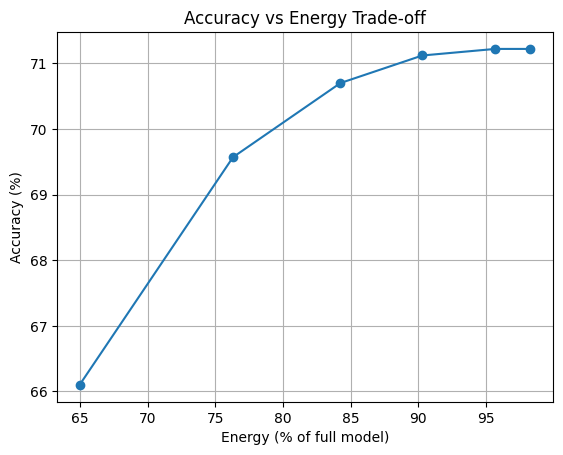

In [11]:
# ================================
# ✅ GRAPH (VERY IMPORTANT)
# ================================
energies = [results[t]["energy"] for t in thresholds]
accuracies = [results[t]["acc"] for t in thresholds]

plt.plot(energies, accuracies, marker='o')
plt.xlabel("Energy (% of full model)")
plt.ylabel("Accuracy (%)")
plt.title("Accuracy vs Energy Trade-off")
plt.grid()
plt.show()